# Capacity normalisation: nameplate power vs. rolling empirical capacity

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pvforecast import preprocessing
from pvforecast.config import FIGURES_DIR, PROCESSED_DIR, RAW_DIR

# Join, gaps and radiation alignment are settled upstream -> just load
df = pd.read_parquet(PROCESSED_DIR / "pv_weather_hourly.parquet")
capacity_monthly = preprocessing.load_capacity(
    RAW_DIR / "capacity_energycharts_solar_2002-2026.csv"
)
pv = df["pv_mwh"]

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"PV: {df.index.min():%Y-%m-%d} bis {df.index.max():%Y-%m-%d} ({len(df):,} h)")
print(
    f"Kapazität: {capacity_monthly.index.min():%Y-%m} bis "
    f"{capacity_monthly.index.max():%Y-%m} ({len(capacity_monthly)} Monatswerte)"
)

PV: 2014-12-31 bis 2025-12-31 (96,433 h)
Kapazität: 2002-01 bis 2026-08 (296 Monatswerte)


## Nameplate normalisation

In [2]:
# Monthly GW -> hourly MW on the PV grid
ac_mw = (
    capacity_monthly["solar_ac_gw"]
    .reindex(capacity_monthly.index.union(pv.index))
    .interpolate("time")
    .reindex(pv.index)
    * 1e3
)

cf_nameplate = pv / ac_mw

print(f"Installiert 2015-01: {ac_mw.iloc[0] / 1e3:.1f} GW AC")
print(f"Installiert 2025-12: {ac_mw.iloc[-1] / 1e3:.1f} GW AC")

Installiert 2015-01: 35.8 GW AC
Installiert 2025-12: 108.9 GW AC


## Rolling empirical capacity

In [3]:
cap_roll = preprocessing.rolling_capacity(pv)
cf_rolling = preprocessing.capacity_factor(pv, cap_roll)

print(f"Erster gültiger Wert: {cap_roll.first_valid_index():%Y-%m-%d %H:%M}")
print(f"Modellstart (Warm-up abgeschlossen): {preprocessing.DATA_START:%Y-%m-%d}")
holes = int(cf_rolling.loc[preprocessing.DATA_START :].isna().sum())
print(f"NaN ab Modellstart: {holes}")

Erster gültiger Wert: 2015-01-02 23:00
Modellstart (Warm-up abgeschlossen): 2016-01-01
NaN ab Modellstart: 0


## Clear summer midday hours

In [4]:
clear_midday = (
    df.index.month.isin([5, 6, 7])
    & df.index.hour.isin([10, 11, 12])
    & (df["shortwave_radiation"] > 600)
)

selected = pd.DataFrame({"nameplate": cf_nameplate, "rolling": cf_rolling})[
    clear_midday
].loc[preprocessing.DATA_START :]

annual = selected.groupby(selected.index.year).agg(["mean", "count"])
annual.columns = ["CF Nennleistung", "n", "CF rollierend", "n2"]
annual = annual[["n", "CF Nennleistung", "CF rollierend"]]

nameplate, rolling = annual["CF Nennleistung"], annual["CF rollierend"]
print(annual.round(3).to_string())
print(
    f"\nNennleistung: {nameplate.iloc[0]:.3f} -> {nameplate.iloc[-1]:.3f} "
    f"({nameplate.iloc[-1] / nameplate.iloc[0] - 1:+.0%})"
)
print(
    f"Rollierend:   {rolling.iloc[0]:.3f} -> {rolling.iloc[-1]:.3f} "
    f"({rolling.iloc[-1] / rolling.iloc[0] - 1:+.0%}), "
    f"Spanne {rolling.min():.2f}-{rolling.max():.2f}"
)

        n  CF Nennleistung  CF rollierend
time                                     
2016  143            0.540          0.854
2017  129            0.556          0.889
2018  179            0.561          0.894
2019  157            0.538          0.882
2020  128            0.517          0.841
2021  126            0.499          0.865
2022  165            0.514          0.911
2023  166            0.468          0.902
2024  144            0.423          0.914
2025  159            0.393          0.861

Nennleistung: 0.540 -> 0.393 (-27%)
Rollierend:   0.854 -> 0.861 (+1%), Spanne 0.84-0.91


## Figure

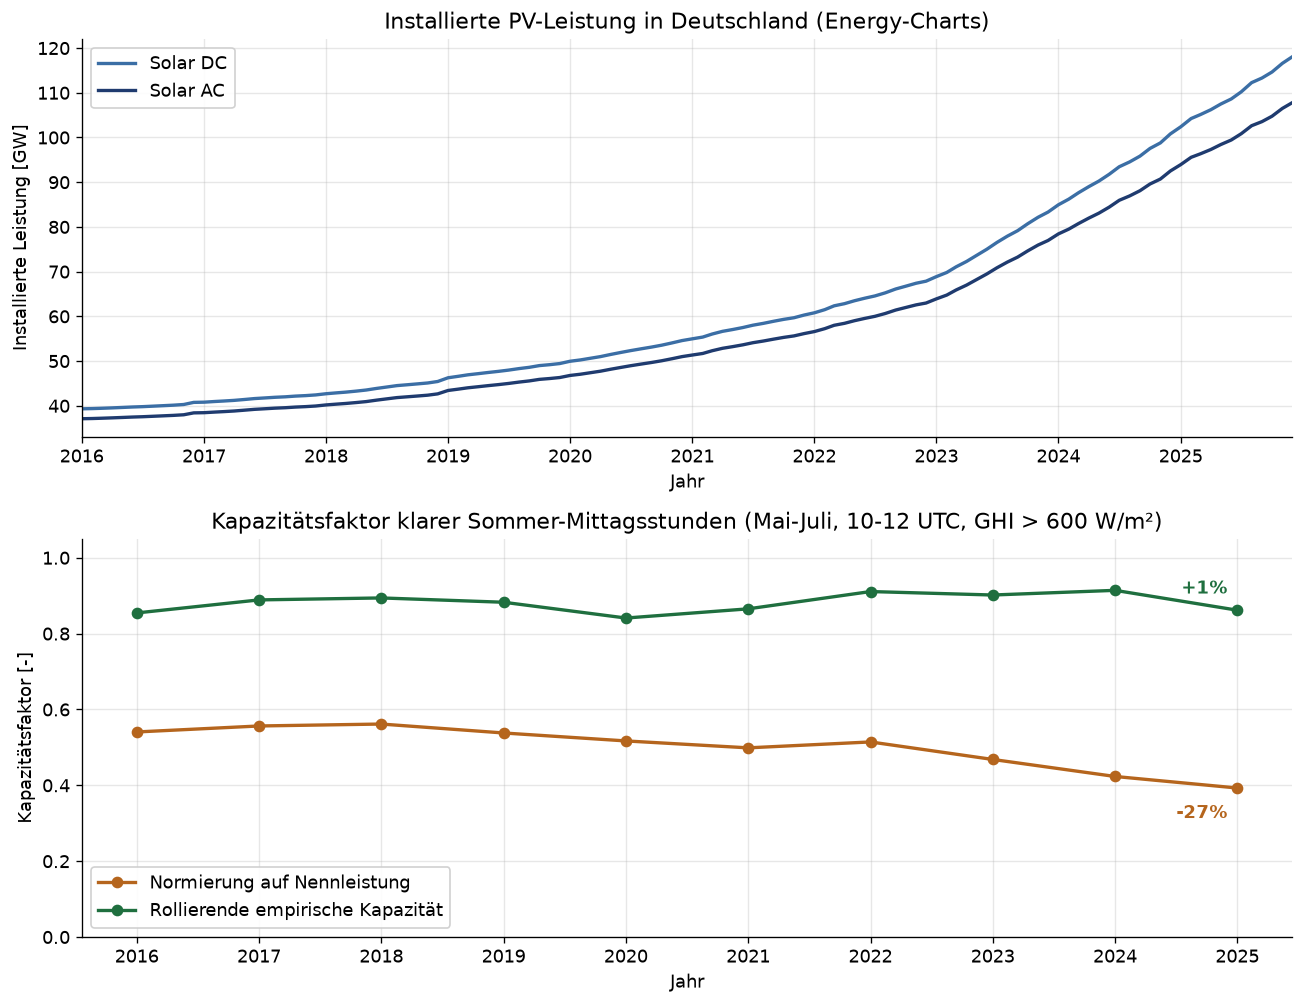

In [5]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8.5))

# (a) The build-out that motivates any normalisation at all
window = capacity_monthly.loc[preprocessing.DATA_START : df.index.max()]
ax_top.plot(
    window.index, window["solar_dc_gw"], color="#3b6ea5", lw=2, label="Solar DC"
)
ax_top.plot(
    window.index, window["solar_ac_gw"], color="#1f3b6f", lw=2, label="Solar AC"
)
ax_top.set_title("Installierte PV-Leistung in Deutschland (Energy-Charts)")
ax_top.set_ylabel("Installierte Leistung [GW]")
ax_top.set_xlabel("Jahr")
ax_top.set_xlim(window.index.min(), window.index.max())
ax_top.legend(loc="upper left", framealpha=0.9)

# (b) Same irradiance conditions, two normalisations
ax_bot.plot(
    nameplate.index,
    nameplate.values,
    color="#b5651d",
    marker="o",
    lw=2,
    label="Normierung auf Nennleistung",
)
ax_bot.plot(
    rolling.index,
    rolling.values,
    color="#1f6f3f",
    marker="o",
    lw=2,
    label="Rollierende empirische Kapazität",
)
ax_bot.set_title(
    "Kapazitätsfaktor klarer Sommer-Mittagsstunden "
    "(Mai-Juli, 10-12 UTC, GHI > 600 W/m²)"
)
ax_bot.set_ylabel("Kapazitätsfaktor [-]")
ax_bot.set_xlabel("Jahr")
ax_bot.set_ylim(0, 1.05)
ax_bot.set_xticks(nameplate.index)
ax_bot.legend(loc="lower left", framealpha=0.9)
ax_bot.annotate(
    f"{nameplate.iloc[-1] / nameplate.iloc[0] - 1:+.0%}",
    xy=(nameplate.index[-1], nameplate.iloc[-1]),
    xytext=(-6, -18),
    textcoords="offset points",
    ha="right",
    color="#b5651d",
    fontweight="bold",
)
ax_bot.annotate(
    f"{rolling.iloc[-1] / rolling.iloc[0] - 1:+.0%}",
    xy=(rolling.index[-1], rolling.iloc[-1]),
    xytext=(-6, 10),
    textcoords="offset points",
    ha="right",
    color="#1f6f3f",
    fontweight="bold",
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_kapazitaetsdrift.png")
plt.show()